In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Methodology

- **Normalization**: Feature-wise mean and std fit on **train inputs only**; applied uniformly to all splits
- **Reduced basis (POD)**: Truncated SVD fit on standardized **train inputs only**
- **DMD**: Linear operator learned in the reduced latent space from (X_train_latent → Y_train_latent)
- **Consistent transform**: Same normalization and basis applied to X_train, Y_train, X_test, Y_test without leakage
- **Prediction**: One-step latent prediction via DMD operator, reconstructed back to original 128×128×2 space
- **Evaluation**: MSE, relative L2, MAE in both standardized and original space; rank sweep on test set

In [2]:
import os
import json
import h5py
import numpy as np
import torch
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.linalg import lstsq

# ── Reproducibility ───────────────────────────────────────────────────────────
SEED = 42
np.random.seed(SEED)

# ── Paths ─────────────────────────────────────────────────────────────────────
TRAIN_DIR  = "/content/drive/MyDrive/gray_scott_data/train"
TEST_DIR   = "/content/drive/MyDrive/gray_scott_data/test"
OUT_DIR    = "/content/drive/MyDrive/gray_scott_data/maze_dmd_rank200_standardized"
os.makedirs(OUT_DIR, exist_ok=True)

TRAIN_FILE = os.path.join(TRAIN_DIR, "maze_train.hdf5")
TEST_FILE  = os.path.join(TEST_DIR,  "maze_test.hdf5")

# ── Config ────────────────────────────────────────────────────────────────────
RANK          = 1500
RANK_SWEEP    = [500, 900, 1000, 1500]
N_VIS_SAMPLES = 5          # number of random test samples to visualize
EPSILON       = 1e-8
DTYPE         = np.float32

print("Output dir :", OUT_DIR)
print("RANK       :", RANK)
print("RANK_SWEEP :", RANK_SWEEP)

Output dir : /content/drive/MyDrive/gray_scott_data/maze_dmd_rank200_standardized
RANK       : 1500
RANK_SWEEP : [500, 900, 1000, 1500]


In [3]:
def inspect_hdf5(path: str) -> None:
    with h5py.File(path, "r") as f:
        print(f"\n{'='*52}")
        print(f"File : {path}")
        print(f"Keys : {list(f.keys())}")
        for key in f.keys():
            print(f"  {key:10s}  shape={f[key].shape}  dtype={f[key].dtype}")

inspect_hdf5(TRAIN_FILE)
inspect_hdf5(TEST_FILE)


File : /content/drive/MyDrive/gray_scott_data/train/maze_train.hdf5
Keys : ['inputs', 'targets']
  inputs      shape=(5000, 1, 128, 128, 2)  dtype=float32
  targets     shape=(5000, 1, 128, 128, 2)  dtype=float32

File : /content/drive/MyDrive/gray_scott_data/test/maze_test.hdf5
Keys : ['inputs', 'targets']
  inputs      shape=(2000, 1, 128, 128, 2)  dtype=float32
  targets     shape=(2000, 1, 128, 128, 2)  dtype=float32


In [4]:
with h5py.File(TRAIN_FILE, "r") as f:
    X_train_raw = f["inputs"][:]    # (5000, 1, 128, 128, 2)
    Y_train_raw = f["targets"][:]   # (5000, 1, 128, 128, 2)

X_train_raw = X_train_raw.astype(DTYPE)
Y_train_raw = Y_train_raw.astype(DTYPE)

print("Train inputs  (raw):", X_train_raw.shape)
print("Train targets (raw):", Y_train_raw.shape)

Train inputs  (raw): (5000, 1, 128, 128, 2)
Train targets (raw): (5000, 1, 128, 128, 2)


In [5]:
with h5py.File(TEST_FILE, "r") as f:
    X_test_raw = f["inputs"][:]     # (2000, 1, 128, 128, 2)
    Y_test_raw = f["targets"][:]    # (2000, 1, 128, 128, 2)

X_test_raw = X_test_raw.astype(DTYPE)
Y_test_raw = Y_test_raw.astype(DTYPE)

print("Test inputs  (raw):", X_test_raw.shape)
print("Test targets (raw):", Y_test_raw.shape)

Test inputs  (raw): (2000, 1, 128, 128, 2)
Test targets (raw): (2000, 1, 128, 128, 2)


In [6]:
# Remove singleton time dim → (N, 128, 128, 2)
X_train_sq = X_train_raw.squeeze(1)
Y_train_sq = Y_train_raw.squeeze(1)
X_test_sq  = X_test_raw.squeeze(1)
Y_test_sq  = Y_test_raw.squeeze(1)

print("After squeeze:")
print("  X_train:", X_train_sq.shape)
print("  Y_train:", Y_train_sq.shape)
print("  X_test :", X_test_sq.shape)
print("  Y_test :", Y_test_sq.shape)

N_TRAIN    = X_train_sq.shape[0]
N_TEST     = X_test_sq.shape[0]
ORIG_SHAPE = X_train_sq.shape[1:]       # (128, 128, 2)
D          = int(np.prod(ORIG_SHAPE))   # 32768

# Flatten spatial + channel dims → (N, D)
X_train_flat = X_train_sq.reshape(N_TRAIN, D)
Y_train_flat = Y_train_sq.reshape(N_TRAIN, D)
X_test_flat  = X_test_sq.reshape(N_TEST,  D)
Y_test_flat  = Y_test_sq.reshape(N_TEST,  D)

print("\nAfter flatten:")
print("  X_train:", X_train_flat.shape)
print("  Y_train:", Y_train_flat.shape)
print("  X_test :", X_test_flat.shape)
print("  Y_test :", Y_test_flat.shape, "  D =", D)

del X_train_raw, Y_train_raw, X_test_raw, Y_test_raw
del X_train_sq,  Y_train_sq,  X_test_sq,  Y_test_sq

After squeeze:
  X_train: (5000, 128, 128, 2)
  Y_train: (5000, 128, 128, 2)
  X_test : (2000, 128, 128, 2)
  Y_test : (2000, 128, 128, 2)

After flatten:
  X_train: (5000, 32768)
  Y_train: (5000, 32768)
  X_test : (2000, 32768)
  Y_test : (2000, 32768)   D = 32768


In [7]:
feat_mean = X_train_flat.mean(axis=0)   # (D,)
feat_std  = X_train_flat.std(axis=0)    # (D,)

print("feat_mean : shape={}, min={:.6f}, max={:.6f}".format(
    feat_mean.shape, feat_mean.min(), feat_mean.max()))
print("feat_std  : shape={}, min={:.6f}, max={:.6f}".format(
    feat_std.shape, feat_std.min(), feat_std.max()))
print("Near-zero std features (< epsilon):", (feat_std < EPSILON).sum())

feat_mean : shape=(32768,), min=0.034993, max=0.731219
feat_std  : shape=(32768,), min=0.027381, max=0.210626
Near-zero std features (< epsilon): 0


In [8]:
def standardize(X, mean, std, eps):
    return (X - mean) / (std + eps)

X_train_std = standardize(X_train_flat, feat_mean, feat_std, EPSILON)
Y_train_std = standardize(Y_train_flat, feat_mean, feat_std, EPSILON)
X_test_std  = standardize(X_test_flat,  feat_mean, feat_std, EPSILON)
Y_test_std  = standardize(Y_test_flat,  feat_mean, feat_std, EPSILON)

print("After standardization:")
print("  X_train_std : shape={}, mean={:.4f}, std={:.4f}".format(
    X_train_std.shape, X_train_std.mean(), X_train_std.std()))
print("  Y_train_std : shape={}".format(Y_train_std.shape))
print("  X_test_std  : shape={}".format(X_test_std.shape))
print("  Y_test_std  : shape={}".format(Y_test_std.shape))

del X_train_flat, Y_train_flat, X_test_flat, Y_test_flat

After standardization:
  X_train_std : shape=(5000, 32768), mean=-0.0000, std=1.0000
  Y_train_std : shape=(5000, 32768)
  X_test_std  : shape=(2000, 32768)
  Y_test_std  : shape=(2000, 32768)


In [9]:
from sklearn.utils.extmath import randomized_svd

RANK       = 1500
RANK_SWEEP = [500, 900, 1000, 1500]

print("Computing TRUNCATED SVD on X_train_std {} ...".format(X_train_std.shape))

# Directly compute top-RANK SVD (no full matrices)
U_r, S_r, Vt_r = randomized_svd(
    X_train_std,
    n_components=RANK,
    n_iter=5,              # good trade-off accuracy/speed
    random_state=SEED
)

# Cast dtype (same as your pipeline)
U_r  = U_r.astype(DTYPE)
S_r  = S_r.astype(DTYPE)
Vt_r = Vt_r.astype(DTYPE)

print("Truncated SVD done.")
print("  U_r  :", U_r.shape)   # (N_TRAIN, RANK)
print("  S_r  :", S_r.shape)   # (RANK,)
print("  Vt_r :", Vt_r.shape)  # (RANK, D)

Computing TRUNCATED SVD on X_train_std (5000, 32768) ...
Truncated SVD done.
  U_r  : (5000, 1500)
  S_r  : (1500,)
  Vt_r : (1500, 32768)


In [12]:
import sys
sys.modules.pop('pandas', None)
sys.modules.pop('sklearn', None)

In [10]:
print("Computing FULL SVD (analysis only) on X_train_std {} ...".format(X_train_std.shape))

# Force float32 to reduce memory
X_tmp = X_train_std.astype(np.float32, copy=False)

# Compute SVD
U_full, S_full, Vt_full = np.linalg.svd(X_tmp, full_matrices=False)

# Immediately free U (not needed for energy plots)
del U_full
import gc; gc.collect()

print("Full SVD done.")
print("  S_full  :", S_full.shape)
print("  Vt_full :", Vt_full.shape)

Computing FULL SVD (analysis only) on X_train_std (5000, 32768) ...
Full SVD done.
  S_full  : (5000,)
  Vt_full : (5000, 32768)


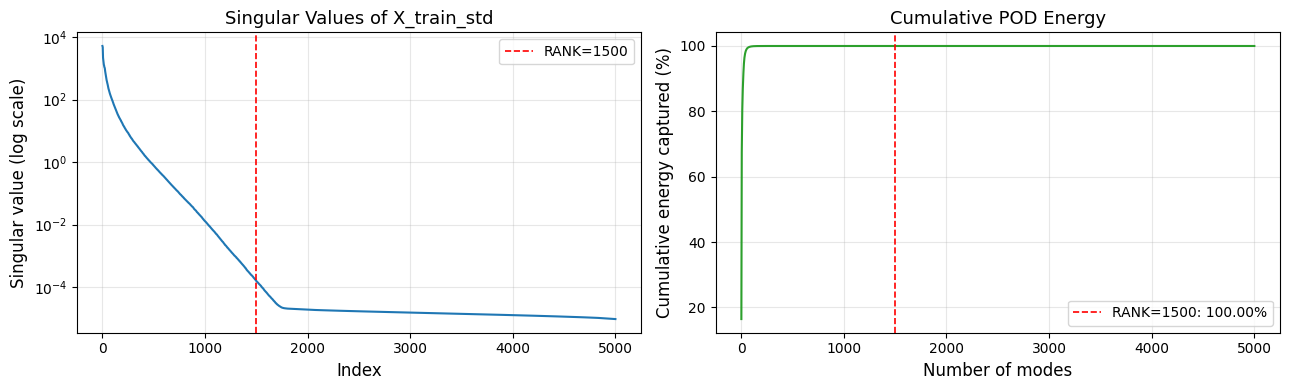

Energy captured by top 1500 modes: 100.000%


In [11]:
eigenvalues = (S_full ** 2) / (N_TRAIN - 1)
cumul_energy = np.cumsum(S_full**2) / np.sum(S_full**2)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: singular values
axes[0].semilogy(np.arange(1, len(S_full) + 1), S_full,
                 color="#1f77b4", linewidth=1.5)
axes[0].axvline(RANK, color="red", linestyle="--", linewidth=1.2,
                label=f"RANK={RANK}")
axes[0].set_xlabel("Index", fontsize=12)
axes[0].set_ylabel("Singular value (log scale)", fontsize=12)
axes[0].set_title("Singular Values of X_train_std", fontsize=13)
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# Right: cumulative energy
axes[1].plot(np.arange(1, len(S_full) + 1), 100 * cumul_energy,
             color="#2ca02c", linewidth=1.5)
axes[1].axvline(RANK, color="red", linestyle="--", linewidth=1.2,
                label=f"RANK={RANK}: {100*cumul_energy[RANK-1]:.2f}%")
axes[1].set_xlabel("Number of modes", fontsize=12)
axes[1].set_ylabel("Cumulative energy captured (%)", fontsize=12)
axes[1].set_title("Cumulative POD Energy", fontsize=13)
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "singular_values_energy.png"), dpi=150, bbox_inches="tight")
plt.show()

print(f"Energy captured by top {RANK} modes: {100*cumul_energy[RANK-1]:.3f}%")

In [12]:
# Projection onto POD basis: Z = X_std @ Vt_r.T  →  (N, RANK)
# Vt_r rows are the principal directions (orthonormal basis vectors in R^D)

def project(X_std, Vt_r):
    return (X_std @ Vt_r.T).astype(DTYPE)   # (N, RANK)

X_train_lat = project(X_train_std, Vt_r)
Y_train_lat = project(Y_train_std, Vt_r)
X_test_lat  = project(X_test_std,  Vt_r)
Y_test_lat  = project(Y_test_std,  Vt_r)

print("Latent representations:")
print("  X_train_lat :", X_train_lat.shape)
print("  Y_train_lat :", Y_train_lat.shape)
print("  X_test_lat  :", X_test_lat.shape)
print("  Y_test_lat  :", Y_test_lat.shape)

Latent representations:
  X_train_lat : (5000, 1500)
  Y_train_lat : (5000, 1500)
  X_test_lat  : (2000, 1500)
  Y_test_lat  : (2000, 1500)


In [13]:
# DMD in latent space (Option A — direct least-squares):
#
#   Find A_r ∈ R^{RANK×RANK} such that  Y_lat ≈ X_lat @ A_r.T
#
# This is equivalent to the classical reduced DMD operator but avoids
# explicitly computing Σ_r^{-1} and handles near-singular cases via lstsq.
#
# Least-squares solution:  A_r.T = argmin || X_lat @ A_r.T - Y_lat ||_F
# i.e., solve:  X_lat.T A_r = Y_lat.T  (each output dimension independently)
# Using scipy lstsq for numerical robustness.

print("Fitting DMD operator in latent space ...")
print("  X_train_lat :", X_train_lat.shape, "  Y_train_lat :", Y_train_lat.shape)

# Solve:  X_lat @ A_r.T = Y_lat   →  A_r.T = lstsq(X_lat, Y_lat)
A_r, residuals, rank_lstsq, sv = lstsq(X_train_lat, Y_train_lat,
                                        cond=None, check_finite=False)
# A_r shape: (RANK, RANK)  — maps latent x_t → latent x_{t+1}
A_r = A_r.astype(DTYPE)

print("DMD operator A_r fitted.")
print("  A_r shape        :", A_r.shape)
print("  lstsq rank       :", rank_lstsq)
print("  ||A_r||_F        : {:.4f}".format(np.linalg.norm(A_r, "fro")))

Fitting DMD operator in latent space ...
  X_train_lat : (5000, 1500)   Y_train_lat : (5000, 1500)
DMD operator A_r fitted.
  A_r shape        : (1500, 1500)
  lstsq rank       : 1203
  ||A_r||_F        : 686.0739


In [14]:
# Predict:  Ŷ_lat = X_lat @ A_r
Y_train_pred_lat = (X_train_lat @ A_r).astype(DTYPE)   # (N_TRAIN, RANK)
Y_test_pred_lat  = (X_test_lat  @ A_r).astype(DTYPE)   # (N_TEST,  RANK)

print("Latent predictions:")
print("  Y_train_pred_lat :", Y_train_pred_lat.shape)
print("  Y_test_pred_lat  :", Y_test_pred_lat.shape)

Latent predictions:
  Y_train_pred_lat : (5000, 1500)
  Y_test_pred_lat  : (2000, 1500)


In [15]:
# -----------------------------------------------------------
# 1) Reconstruction function (UNCHANGED)
# -----------------------------------------------------------
def reconstruct(Z_lat, Vt_r, feat_mean, feat_std, eps, orig_shape):
    X_std_hat = (Z_lat @ Vt_r).astype(DTYPE)
    X_orig    = X_std_hat * (feat_std + eps) + feat_mean
    return X_orig.reshape(-1, *orig_shape)

# -----------------------------------------------------------
# 2) Reconstruct ONLY predictions (CORRECT)
# -----------------------------------------------------------
Y_train_pred_orig = reconstruct(Y_train_pred_lat, Vt_r, feat_mean, feat_std,
                               EPSILON, ORIG_SHAPE)

Y_test_pred_orig  = reconstruct(Y_test_pred_lat,  Vt_r, feat_mean, feat_std,
                               EPSILON, ORIG_SHAPE)

# -----------------------------------------------------------
# 3) Reload RAW data (CRITICAL FIX)
# -----------------------------------------------------------
import h5py

with h5py.File(os.path.join(TEST_DIR, "maze_test.hdf5"), "r") as f:
    X_test_raw = f["inputs"][:]    # (N, 1, 128, 128, 2)
    Y_test_raw = f["targets"][:]   # (N, 1, 128, 128, 2)

with h5py.File(os.path.join(TRAIN_DIR, "maze_train.hdf5"), "r") as f:
    Y_train_raw = f["targets"][:]

# Remove singleton dimension
X_test_orig      = X_test_raw[:, 0].astype(DTYPE)
Y_test_true_orig = Y_test_raw[:, 0].astype(DTYPE)
Y_train_true_orig = Y_train_raw[:, 0].astype(DTYPE)

# -----------------------------------------------------------
# 4) Sanity check
# -----------------------------------------------------------
print("Shapes after FIX:")
print("  Y_train_pred_orig :", Y_train_pred_orig.shape)
print("  Y_test_pred_orig  :", Y_test_pred_orig.shape)
print("  Y_train_true_orig :", Y_train_true_orig.shape)
print("  Y_test_true_orig  :", Y_test_true_orig.shape)
print("  X_test_orig       :", X_test_orig.shape)

Shapes after FIX:
  Y_train_pred_orig : (5000, 128, 128, 2)
  Y_test_pred_orig  : (2000, 128, 128, 2)
  Y_train_true_orig : (5000, 128, 128, 2)
  Y_test_true_orig  : (2000, 128, 128, 2)
  X_test_orig       : (2000, 128, 128, 2)


In [16]:
def compute_metrics(y_true, y_pred, label: str) -> dict:
    """Compute MSE, relative L2, MAE.  Arrays may be any shape (N, ...)."""
    diff    = y_pred - y_true
    mse     = float(np.mean(diff ** 2))
    rel_l2  = float(np.linalg.norm(diff) / (np.linalg.norm(y_true) + EPSILON))
    mae     = float(np.mean(np.abs(diff)))
    print(f"  [{label}]  MSE={mse:.6e}  |  rel_L2={rel_l2:.6e}  |  MAE={mae:.6e}")
    return {"mse": mse, "rel_l2": rel_l2, "mae": mae}

print("─── Standardized latent space ───────────────────────────────────────")
m_train_lat = compute_metrics(Y_train_lat, Y_train_pred_lat, "train | latent")
m_test_lat  = compute_metrics(Y_test_lat,  Y_test_pred_lat,  "test  | latent")

print("\n─── Reconstructed original space ────────────────────────────────────")
m_train_orig = compute_metrics(Y_train_true_orig, Y_train_pred_orig, "train | orig")
m_test_orig  = compute_metrics(Y_test_true_orig,  Y_test_pred_orig,  "test  | orig")

─── Standardized latent space ───────────────────────────────────────
  [train | latent]  MSE=7.619116e-07  |  rel_L2=1.872151e-04  |  MAE=1.588542e-04
  [test  | latent]  MSE=6.810520e+01  |  rel_L2=1.906157e+00  |  MAE=2.376944e+00

─── Reconstructed original space ────────────────────────────────────
  [train | orig]  MSE=6.383963e-10  |  rel_L2=6.115150e-05  |  MAE=1.675553e-05
  [test  | orig]  MSE=6.616488e-02  |  rel_L2=6.159247e-01  |  MAE=1.727487e-01


In [17]:
def fit_and_eval_dmd(rank: int) -> dict:
    """Fit DMD at given rank, evaluate on test set, return metrics."""
    Vt_k  = Vt_full[:rank, :].astype(DTYPE)

    Xtr_k = (X_train_std @ Vt_k.T).astype(DTYPE)
    Ytr_k = (Y_train_std @ Vt_k.T).astype(DTYPE)
    Xte_k = (X_test_std  @ Vt_k.T).astype(DTYPE)
    Yte_k = (Y_test_std  @ Vt_k.T).astype(DTYPE)

    A_k, *_ = lstsq(Xtr_k, Ytr_k, cond=None, check_finite=False)
    A_k = A_k.astype(DTYPE)

    Ypred_k = (Xte_k @ A_k).astype(DTYPE)

    # --------------------------------------------------
    # LATENT METRICS (unchanged, correct)
    # --------------------------------------------------
    diff   = Ypred_k - Yte_k
    mse    = float(np.mean(diff ** 2))
    rel_l2 = float(np.linalg.norm(diff) / (np.linalg.norm(Yte_k) + EPSILON))
    mae    = float(np.mean(np.abs(diff)))

    # --------------------------------------------------
    # ORIGINAL SPACE METRICS (FIXED)
    # --------------------------------------------------

    # Prediction → reconstruct (CORRECT)
    Ypred_orig = (Ypred_k @ Vt_k) * (feat_std + EPSILON) + feat_mean

    # Ground truth → RAW (NOT reconstructed)
    # assumes Y_test_true_orig already exists from raw HDF5
    Ytrue_orig = Y_test_true_orig.reshape(Ypred_orig.shape)

    diff_o   = Ypred_orig - Ytrue_orig
    mse_o    = float(np.mean(diff_o ** 2))
    rel_l2_o = float(np.linalg.norm(diff_o) / (np.linalg.norm(Ytrue_orig) + EPSILON))
    mae_o    = float(np.mean(np.abs(diff_o)))

    return {
        "rank": rank,
        "lat_mse": mse, "lat_rel_l2": rel_l2, "lat_mae": mae,
        "orig_mse": mse_o, "orig_rel_l2": rel_l2_o, "orig_mae": mae_o
    }


print("Running rank sweep: {}\n".format(RANK_SWEEP))
sweep_results = []

for r in RANK_SWEEP:
    res = fit_and_eval_dmd(r)
    sweep_results.append(res)

    print("  rank={:>3d}  lat_MSE={:.4e}  orig_MSE={:.4e}  "
          "orig_relL2={:.4e}".format(
            r, res["lat_mse"], res["orig_mse"], res["orig_rel_l2"]))

Running rank sweep: [500, 900, 1000, 1500]

  rank=500  lat_MSE=7.2015e+00  orig_MSE=1.5224e-02  orig_relL2=2.9568e-01
  rank=900  lat_MSE=3.1253e+02  orig_MSE=1.7099e-01  orig_relL2=9.9099e-01
  rank=1000  lat_MSE=1.4105e+02  orig_MSE=8.9927e-02  orig_relL2=7.1841e-01
  rank=1500  lat_MSE=2.1848e+02  orig_MSE=1.9294e-01  orig_relL2=1.0530e+00


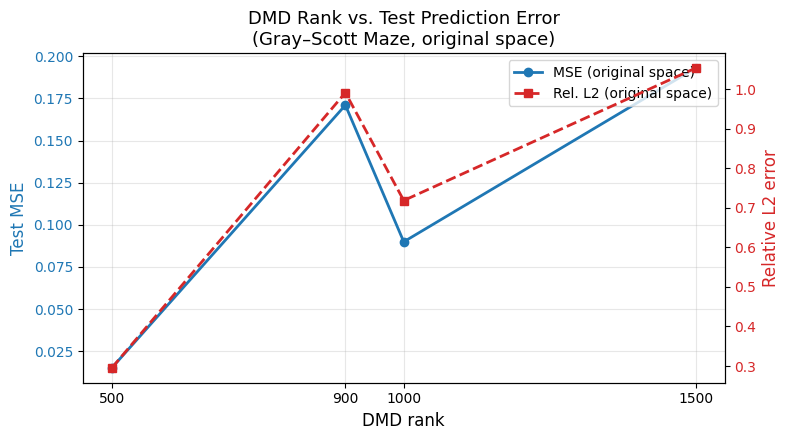

Saved: rank_vs_error.png


In [18]:
ranks     = [r["rank"]       for r in sweep_results]
orig_mse  = [r["orig_mse"]   for r in sweep_results]
orig_rl2  = [r["orig_rel_l2"] for r in sweep_results]

fig, ax1 = plt.subplots(figsize=(8, 4.5))

color_mse = "#1f77b4"
color_rl2 = "#d62728"

ax1.plot(ranks, orig_mse, "o-", color=color_mse, linewidth=2,
         markersize=6, label="MSE (original space)")
ax1.set_xlabel("DMD rank", fontsize=12)
ax1.set_ylabel("Test MSE", fontsize=12, color=color_mse)
ax1.tick_params(axis="y", labelcolor=color_mse)
ax1.set_xticks(ranks)
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
ax2.plot(ranks, orig_rl2, "s--", color=color_rl2, linewidth=2,
         markersize=6, label="Rel. L2 (original space)")
ax2.set_ylabel("Relative L2 error", fontsize=12, color=color_rl2)
ax2.tick_params(axis="y", labelcolor=color_rl2)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=10, loc="upper right")

plt.title("DMD Rank vs. Test Prediction Error\n(Gray–Scott Maze, original space)",
          fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "rank_vs_error.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Saved: rank_vs_error.png")

Visualizing test samples: [178, 866, 877, 1307, 1545]


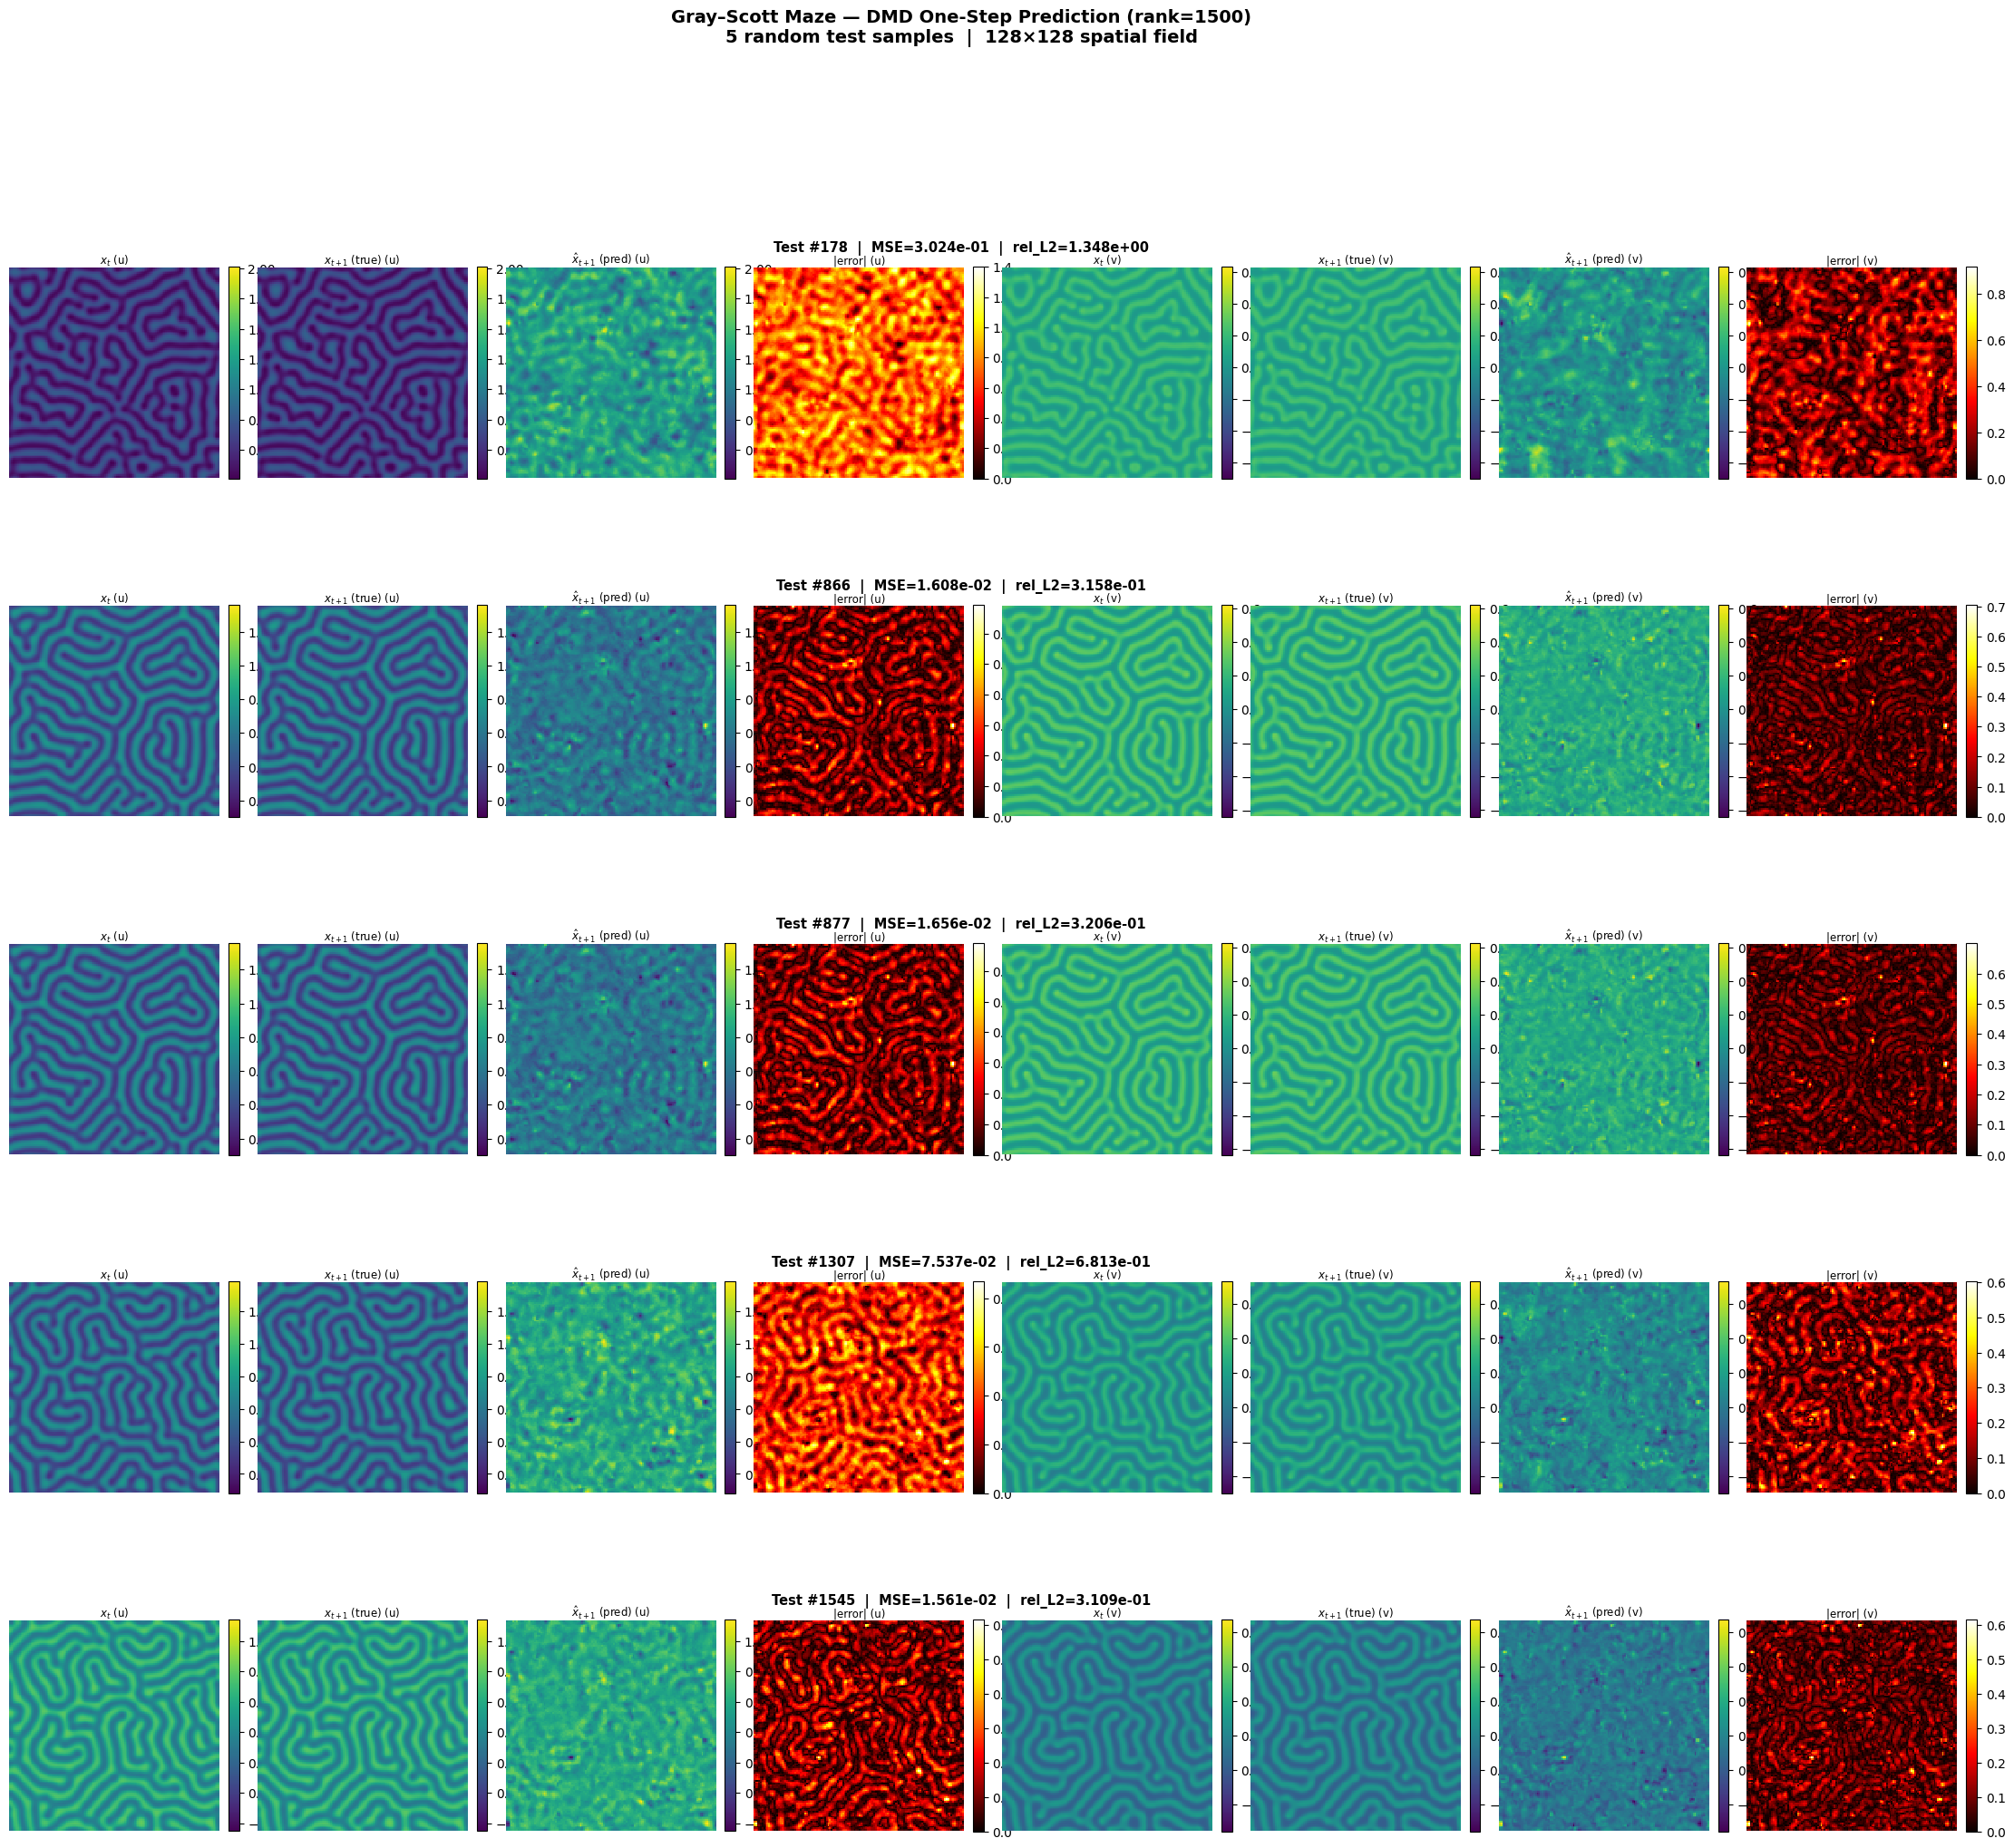

Saved: random_test_predictions.png


In [19]:
rng         = np.random.default_rng(SEED)
vis_indices = rng.choice(N_TEST, size=N_VIS_SAMPLES, replace=False)
vis_indices = sorted(vis_indices.tolist())
print("Visualizing test samples:", vis_indices)

# Rows: one per sample
# Cols (per channel): x_t | y_true | y_pred | |error|
# 2 channels × 4 panels = 8 columns total
N_COLS = 8

fig = plt.figure(figsize=(28, 4.5 * N_VIS_SAMPLES))
outer = gridspec.GridSpec(N_VIS_SAMPLES, 1, figure=fig, hspace=0.55)

ch_labels = ["u", "v"]
panel_titles_base = ["$x_t$", "$x_{t+1}$ (true)", r"$\hat{x}_{t+1}$ (pred)", "|error|"]

for row_idx, idx in enumerate(vis_indices):
    x_curr  = X_test_orig[idx]            # (128, 128, 2)  current state
    y_true  = Y_test_true_orig[idx]       # (128, 128, 2)  true next state
    y_pred  = Y_test_pred_orig[idx]       # (128, 128, 2)  predicted next state

    mse_s = float(np.mean((y_pred - y_true) ** 2))
    rl2_s = float(np.linalg.norm(y_pred - y_true) /
                  (np.linalg.norm(y_true) + EPSILON))

    inner = gridspec.GridSpecFromSubplotSpec(
        1, N_COLS, subplot_spec=outer[row_idx], wspace=0.08
    )

    row_label = (f"Test #{idx}  |  MSE={mse_s:.3e}  |  rel_L2={rl2_s:.3e}")
    ypos = outer[row_idx].get_position(fig).y1 + 0.004
    fig.text(0.5, ypos, row_label, ha="center", va="bottom",
             fontsize=10.5, fontweight="bold")

    col = 0
    for ch, ch_label in enumerate(ch_labels):
        imgs  = [x_curr[:, :, ch], y_true[:, :, ch],
                 y_pred[:, :, ch],  np.abs(y_true[:, :, ch] - y_pred[:, :, ch])]
        cmaps = ["viridis", "viridis", "viridis", "hot"]

        vmin_img = min(imgs[0].min(), imgs[1].min(), imgs[2].min())
        vmax_img = max(imgs[0].max(), imgs[1].max(), imgs[2].max())
        vlims    = [(vmin_img, vmax_img)] * 3 + [(0, imgs[3].max())]

        for p_idx, (img, cmap, (vlo, vhi)) in enumerate(zip(imgs, cmaps, vlims)):
            ax = fig.add_subplot(inner[0, col])
            im = ax.imshow(img, cmap=cmap, vmin=vlo, vmax=vhi,
                           interpolation="nearest", aspect="equal")
            ax.set_title(f"{panel_titles_base[p_idx]} ({ch_label})",
                         fontsize=8.5, pad=3)
            ax.axis("off")
            plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
            col += 1

plt.suptitle(
    f"Gray–Scott Maze — DMD One-Step Prediction (rank={RANK})\n"
    f"{N_VIS_SAMPLES} random test samples  |  128×128 spatial field",
    fontsize=14, fontweight="bold", y=1.005
)
plt.savefig(os.path.join(OUT_DIR, "random_test_predictions.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print("Saved: random_test_predictions.png")